## <h1 style="color: #9983b8;"> Install Libraries </h1>

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install plotly
!pip install joblib
!pip install jupyter
!pip install ipykernel

  Using cached pandas-2.3.3-cp310-cp310-macosx_10_9_x86_64.whl (11.6 MB)
  Using cached numpy-2.2.6-cp310-cp310-macosx_10_9_x86_64.whl (21.2 MB)
  Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached matplotlib-3.10.9-cp310-cp310-macosx_10_12_x86_64.whl (8.3 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached fonttools-4.63.0-cp310-cp310-macosx_10_9_x86_64.whl (2.4 MB)
  Using cached pillow-12.2.0-cp310-cp310-macosx_10_10_x86_64.whl (5.4 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-macosx_10_9_x86_64.whl (66 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_10_9_x86_64.whl (268 kB)

[notice] A new release of pi

## <h1 style="color: #9983b8;">Import Libraries</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

print("All core libraries installed successfully.")

All core libraries installed successfully.


## <h1 style="color: #9983b8;">Load dataset & inspect</h1>

In [29]:
df = pd.read_csv("/Users/laxmigupte/Desktop/Forest-fire-risk-project/data/raw/forestfires.csv")
print("Raw dataset loaded successfully.")

Raw dataset loaded successfully.


In [4]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## <h3 style="color: #9983b8;">Understand Data Structure</h3>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


## <h3 style="color: #9983b8;">Explore numerical data</h3>

In [6]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


## <h3 style="color: #9983b8;">Plot numerical feature distributions</h3>

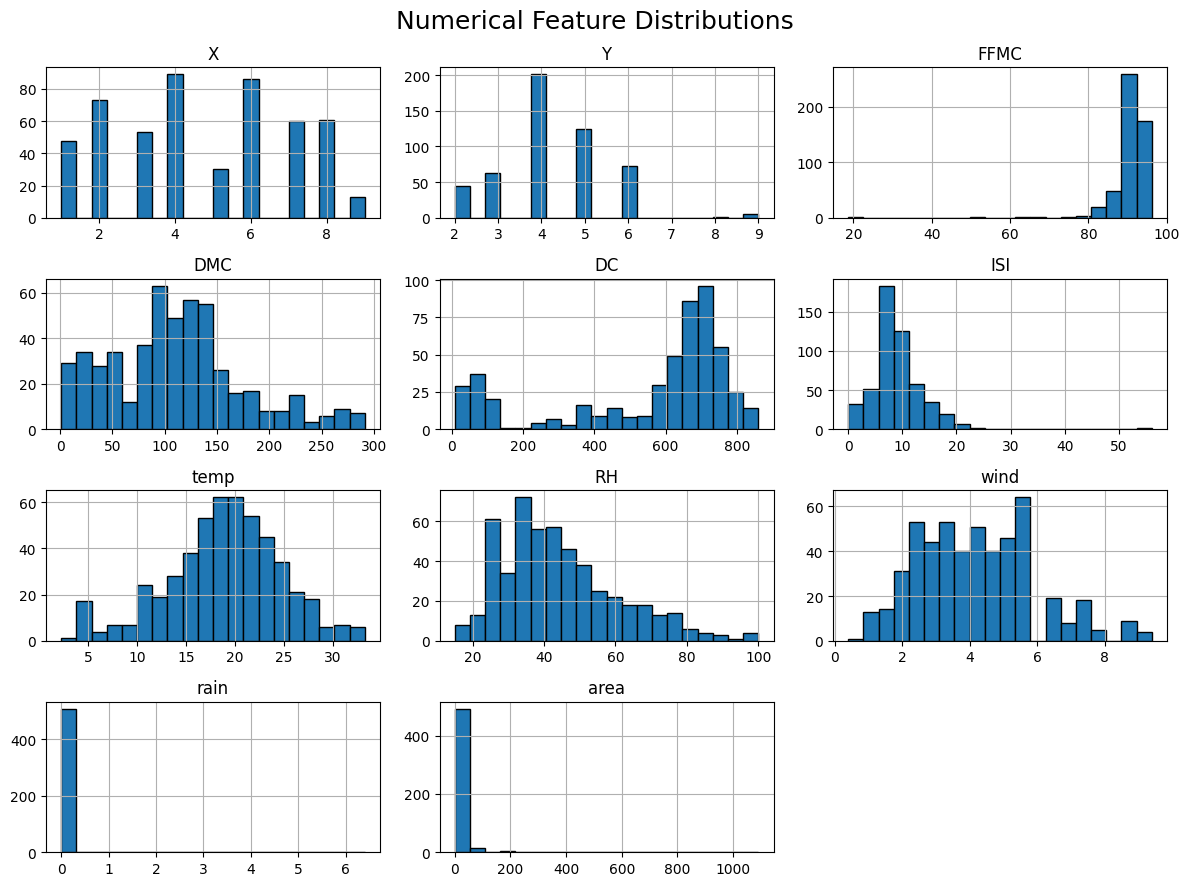

In [19]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_columns].hist(
    figsize=(12, 9),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Numerical Feature Distributions", fontsize=18)
plt.tight_layout()
plt.show()

## <h4 style="color: #60b9e5;"> Insight: Wildfire burned area distribution is highly skewed, with most fires affecting small areas and only a few extreme wildfire events.</h4>

## <h3 style="color: #9983b8;">View target</h3>

<Axes: xlabel='area', ylabel='Count'>

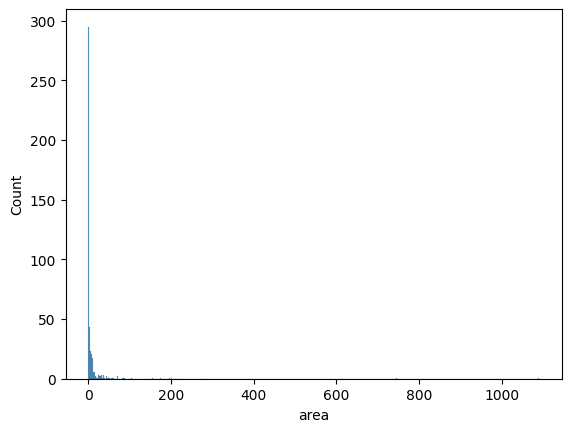

In [27]:
sns.histplot(df["area"])

## <h3 style="color: #9983b8;">Explore categorical data</h3>

In [15]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: month
month
aug    182
sep    172
mar     53
jul     32
feb     20
jun     16
oct     15
apr      9
dec      9
jan      2
may      2
nov      1
Name: count, dtype: int64

Column: day
day
sun    94
fri    84
sat    83
mon    74
tue    64
thu    61
wed    53
Name: count, dtype: int64


## <h3 style="color: #9983b8;">Plot categorical feature distributions</h3>

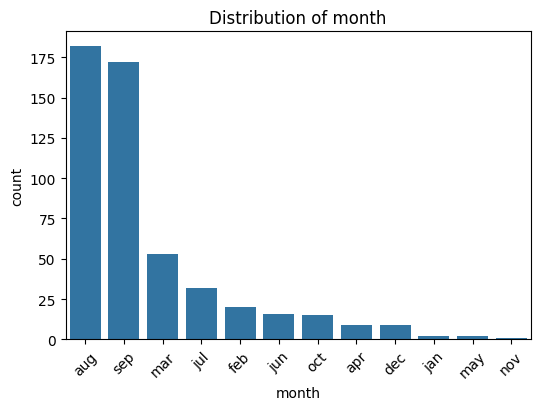

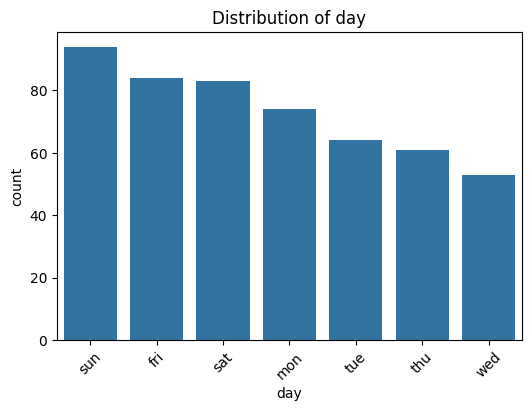

In [21]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

## <h3 style="color: #9983b8;">Check missing values</h3>

In [7]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

## <h3 style="color: #9983b8;">Check duplicated values & drop them</h3>

In [8]:
df.duplicated().sum()

np.int64(4)

In [11]:
df[df.duplicated(keep=False)]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

## <h3 style="color: #9983b8;">Rename columns</h3>

In [24]:
df.rename(columns={
    'X': 'x_coordinate',
    'Y': 'y_coordinate',
    'FFMC': 'fine_fuel_moisture_code',
    'DMC': 'duff_moisture_code',
    'DC': 'drought_code',
    'ISI': 'initial_spread_index',
    'RH': 'relative_humidity'
}, inplace=True)

In [26]:
df.columns

Index(['x_coordinate', 'y_coordinate', 'month', 'day',
       'fine_fuel_moisture_code', 'duff_moisture_code', 'drought_code',
       'initial_spread_index', 'temp', 'relative_humidity', 'wind', 'rain',
       'area'],
      dtype='object')

## <h3 style="color: #9983b8;">Save cleaned dataset</h3>

In [28]:
df.to_csv("../data/processed/forestfires_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## <h1 style="color: #c63b4b;">Notebook conclusion</h1>


Installed & Imported libraries

Loaded dataset

Explored numerical features

Explored categorical features

Visualized distributions

Removed duplicates

Verified missing values

Renamed columns

Saved cleaned dataset